In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder


### Step 1: Create Sample DataSet

In [2]:

data = {
    'Hours_Studied' : [1,2,3,4,5,6,7,8,9,10],
    'Sleep_Hours' : [8,7,6,6,5,5,4,3,3,2],
    'Result' : ['Fail','Fail','Fail','Fail','Pass','Pass','Pass','Pass','Pass','Pass']

}

df = pd.DataFrame(data)
print(df)



   Hours_Studied  Sleep_Hours Result
0              1            8   Fail
1              2            7   Fail
2              3            6   Fail
3              4            6   Fail
4              5            5   Pass
5              6            5   Pass
6              7            4   Pass
7              8            3   Pass
8              9            3   Pass
9             10            2   Pass


In [3]:
X = df[['Hours_Studied','Sleep_Hours' ]]
y = df['Result']



### Step 2: Train Test Split

In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

### Step 3: Train Naive Bayes

In [5]:
model = GaussianNB()
model.fit(X_train,y_train)


GaussianNB()

### step 4: Make Prediction

In [6]:
y_pred = model.predict(X_test)
print("Predictions: ", y_pred)

Predictions:  ['Pass' 'Fail']


### Step 5: Evaluate the model

In [7]:
print("\nConfusion Matrix:\n",confusion_matrix(y_test, y_pred))
print("\nAccuracy: ", accuracy_score(y_test,y_pred))
print("\nClassification  Report: \n", classification_report(y_test,y_pred))



Confusion Matrix:
 [[1 0]
 [0 1]]

Accuracy:  1.0

Classification  Report: 
               precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         1
        Pass       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



### Step 6: Visualisation

In [ ]:
plt.figure(figsize=(7,5))

x_min, x_max = X['Hours_Studied'].min() - 1, X['Hours_Studied'].max() + 1

y_min, y_max = X['Sleep_Hours'].min() - 1, X['Sleep_Hours'].max() + 1

xx, yy = np.meshgrid(np.arange(x_min,x_max,0.1),
                     np.arange(y_min,y_max,0.1))
Z = model.predict(pd.DataFrame(np.c_[xx.ravel(), yy.ravel()],columns = X.columns))


<Figure size 700x500 with 0 Axes>


### Step 7: Encode labels to number for contourf

In [17]:
le = LabelEncoder()
le.fit(model.classes_)
Z = le.transform(Z)
Z = Z.reshape(xx.shape)

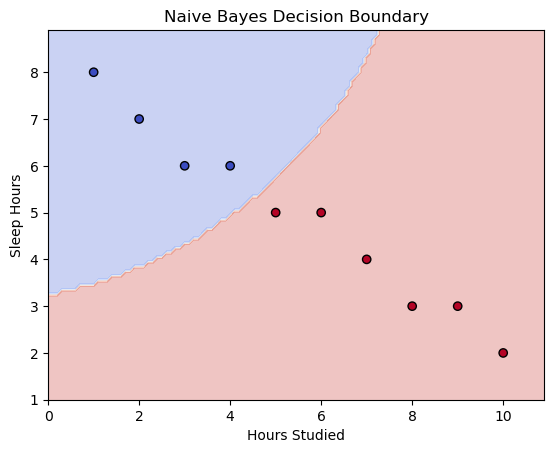

In [18]:
plt.contourf(xx,yy,Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X['Hours_Studied'],X['Sleep_Hours'], c = le.transform(y), cmap='coolwarm', edgecolors='k')
plt.xlabel('Hours Studied')
plt.ylabel('Sleep Hours')
plt.title('Naive Bayes Decision Boundary')
plt.show()

### Step 8: Predictor

In [19]:
# Predict for a new student
new_student = [[6,5]]
result = model.predict(new_student)
print("\n Prediction for new student: ", result)


 Prediction for new student:  ['Pass']


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


### Best is Gaussian RBF model